# Treasure Hunt Game Notebook

## Read and Review Your Starter Code
The theme of this project is a popular treasure hunt game in which the player needs to find the treasure before the pirate does. While you will not be developing the entire game, you will write the part of the game that represents the intelligent agent, which is a pirate in this case. The pirate will try to find the optimal path to the treasure using deep Q-learning.
You have been provided with two Python classes and this notebook to help you with this assignment. The first class, <b>TreasureMaze.py</b>, represents the environment, which includes a maze object defined as a matrix. The second class, <b>GameExperience.py</b>, stores the episodes – that is, all the states that come in between the initial state and the terminal state. This is later used by the agent for learning by experience, called "exploration". This notebook shows how to play a game. Your task is to complete the deep Q-learning implementation in the qtrain() function for which a skeleton implementation has been provided.

<div class="alert alert-block alert-warning" style="color: #333333;">
<b>Installations</b> The following command will install the necessary Python libraries to necessary to run this application. If you see a "[notice] A new release of pip is available: 23.1.2 -> 25.2" at the end of the installation, you may disregard that statement. 
</div>

In [1]:
!python -m pip install --upgrade pip
!python -m pip install -r requirements.txt

<h2>Imports and Dependencies</h2>

In [2]:
from __future__ import print_function
import os, sys, time, datetime, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import clone_model
from keras.models import Sequential
from keras.layers import Dense, Activation, PReLU
from keras.optimizers import SGD , Adam, RMSprop
import matplotlib.pyplot as plt
from TreasureMaze import TreasureMaze
from GameExperience import GameExperience
%matplotlib inline

<h2> Maze Object Generation</h2>

<div class="alert alert-block alert-info" style="color:black;">
    <b>NOTE:</b>  The following code block contains an 8x8 matrix that will be used as a maze object:
</div>

In [3]:
maze = np.array([
    [ 1.,  0.,  1.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  0.,  1.,  1.,  1.,  0.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  0.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]
])

<h2>Helper Functions and Global Variables</h2>

<div class="alert alert-block alert-info" style="color:black;">
This <b>show()</b> helper function allows a visual representation of the maze object:
</div>

In [4]:
def show(qmaze):
    plt.grid('on')
    nrows, ncols = qmaze.maze.shape
    ax = plt.gca()
    ax.set_xticks(np.arange(0.5, nrows, 1))
    ax.set_yticks(np.arange(0.5, ncols, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    canvas = np.copy(qmaze.maze)
    for row,col in qmaze.visited:
        canvas[row,col] = 0.6
    pirate_row, pirate_col, _ = qmaze.state
    canvas[pirate_row, pirate_col] = 0.3   # pirate cell
    canvas[nrows-1, ncols-1] = 0.9 # treasure cell
    img = plt.imshow(canvas, interpolation='none', cmap='gray')
    return img

The <b>pirate agent</b> can move in four directions: left, right, up, and down. 

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note:</b> While the agent primarily learns by experience through exploitation, often, the agent can choose to explore the environment to find previously undiscovered paths. This is called "exploration" and is defined by epsilon. This value is the <b>EXPLORATION</b> values from the Cartpole assignment. The hyperparameters are provided here and used in the <b>qtrain()</b> method. 
You are encouraged to try various values for the exploration factor and see how the algorithm performs.
</div>

In [5]:
LEFT = 0
UP = 1
RIGHT = 2
DOWN = 3


# Exploration factor
epsilon = 0.05
epsilon_min = 0.05
epsilon_decay = 0.995
patience = 10

# Actions dictionary
actions_dict = {
    LEFT: 'left',
    UP: 'up',
    RIGHT: 'right',
    DOWN: 'down',
}

num_actions = len(actions_dict)


The sample code block and output below show creating a maze object and performing one action (DOWN), which returns the reward. The resulting updated environment is visualized.

reward= -0.04


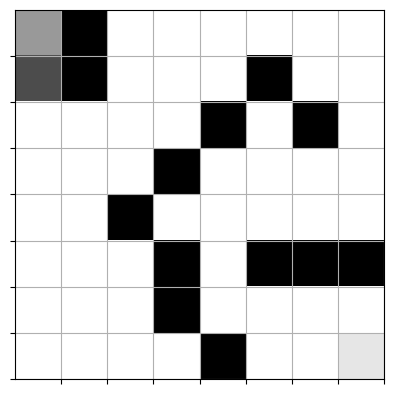

In [6]:
qmaze = TreasureMaze(maze)
canvas, reward, game_over = qmaze.act(DOWN)
print("reward=", reward)
show(qmaze)

<div class="alert alert-block alert-warning" style="color:black;">
    <b>NOTE:</b> This <b>play_game()</b> function simulates a full game based on the provided trained model. The other parameters include the TreasureMaze object, the starting position of the pirate and max amount of steps to make sure the code does not get stuck in a loop.
</div>

In [7]:
def play_game(model, qmaze, pirate_cell, max_steps=None):
    qmaze.reset(pirate_cell)
    envstate = qmaze.observe()
    steps = 0
    if max_steps is None:
        max_steps = qmaze.maze.size * 4  # safety cutoff

    while steps < max_steps:
        state = np.asarray(envstate, dtype=np.float32)
        if state.ndim == 1:
            state = np.expand_dims(state, axis=0)

        q_values = model(state, training=False).numpy()
        action = np.argmax(q_values[0])

        envstate, reward, game_status = qmaze.act(action)
        steps += 1

        if game_status == 'win':
            return True
        elif game_status == 'lose':
            return False

    return False  # timed out with no result

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b>
    This <b>completion_check()</b> function helps you to determine whether the pirate can win any game at all. If your maze is not well designed, the pirate may not win any game at all. In this case, your training would not yield any result. The provided maze in this notebook ensures that there is a path to win and you can run this method to check.
</div>

In [8]:
def completion_check(model, maze_or_qmaze, max_steps=None):
    # Accept either raw numpy maze or TreasureMaze instance
    if isinstance(maze_or_qmaze, TreasureMaze):
        qmaze = maze_or_qmaze
    else:
        qmaze = TreasureMaze(maze_or_qmaze)

    for cell in qmaze.free_cells:
        if not qmaze.valid_actions(cell):
            continue
        if not play_game(model, qmaze, cell, max_steps=max_steps):
            return False
    return True

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b>
</b>The <b>build_model()</b> function in the block below will build the neural network model. Review the code and note the number of layers, as well as the activation, optimizer, and loss functions that are used to train the model.
</div>

In [9]:
def build_model(maze):
    model = Sequential()
    model.add(Dense(maze.size, input_shape=(maze.size,)))
    model.add(PReLU())
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(num_actions))
    model.compile(optimizer='adam', loss='mse')
    return model

<div class="alert alert-block alert-warning" style="color:black;">
    <b>Note:</b>
    This <b>train_step()</b> helper function in the block below is used to help predict Q-values (quality values) in the current modelto see how good each action is in a given state and improve the Q-network by reducing the gap between what is predicted and what should have been predicted. 
</div>

In [10]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        q_values = model(x, training=True)
        loss = loss_fn(y, q_values)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# Q-Training Algorithm Code Block

<div class="alert alert-block alert-warning" style="color:black;">
    <b>Note:</b>
The following code implements the DQN training algorithm. Pseudocode comments are retained from the assignment template to map each implementation step to the algorithmic description provided.<br> Additional implementation details (target network updates, epsilon decay, win rate tracking) have been added as required for the DQN agent to learn effectively.
</div>

In [11]:
def qtrain(model, maze, **opt):
    # exploration factor
    global epsilon
    
    # Number of epochs
    n_epoch = opt.get('n_epoch', 15000)
    
    # Maximum meory to store episodes
    max_memory = opt.get('max_memory', 1000)
    
    # Maximum data size for training
    data_size = opt.get('data_size', 50)
    
    # Frequency of target network updates
    target_update_freq = opt.get('target_update_freq', 50)
    
    # Start time
    start_time = datetime.datetime.now()
    
    # Construct environment/game from numpy array: maze (see argument above)
    qmaze = TreasureMaze(maze)
    
    # Target Network to better guide training
    target_model = clone_model(model)
    target_model.set_weights(model.get_weights())
    
    # Initialize experience replay object
    experience = GameExperience(model, target_model, max_memory=max_memory)

    win_history = [] # history of win/lose game
    hsize = qmaze.maze.size // 2 #history window size
    win_rate = 0.0
    
    # =============START_HERE================
    
    # [PSEUDOCODE] For each epoch: Reset the environment at a random starting cell
    for epoch in range(n_epoch):

        # [PSEUDOCODE] agent_cell = randomly select a free cell
        pirate_cell = random.choice(qmaze.free_cells)
        qmaze.reset(pirate_cell)

        # [PSEUDOCODE] Set the initial environment state
        envstate = qmaze.observe()
        
        game_status = 'not_over'
        n_episodes = 0
        loss = 0.0

        # [PSEUDOCODE] While game status is not game over:
        while game_status == 'not_over':

            # [PSEUDOCODE] previous_envstate = env_state
            previous_envstate = envstate

            # [PSEUDOCODE] Decide on an action:
            # - If possible, take a random valid exploration action and
            #   randomly choose action (left, right, up, down)
            # - Else, pick the best exploitation action from the model
            valid_actions = qmaze.valid_actions()
            if not valid_actions: 
                break

            if np.random.rand() < epsilon:
                action = random.choice(valid_actions) # Explore
            else:
                action = np.argmax(experience.predict(previous_envstate)) # Exploit

            # [PSEUDOCODE] Retrieve the values below from the act() method.
            envstate, reward, game_status = qmaze.act(action)

            # [PSEUDOCODE] Track the wins and losses from the game_status using win_history
            if game_status == 'win':
                win_history.append(1)
                game_over = True
            elif game_status == 'lose':
                win_history.append(0)
                game_over = True
            else:
                game_over = False

            # [PSEUDOCODE] Store the episode below in the Experience replay object
            episode = [
                previous_envstate,
                action,
                reward,
                envstate,
                game_status
            ]
            # Count this step for performance tracking
            n_episodes += 1 
            # Save this experience to learn from it later
            experience.remember(episode)

            # [PSEUDOCODE] Train neural network model and evaluate loss
            # Sample random experience batch and update network weights
            inputs, targets = experience.get_data(data_size)   # Get random training batch
            batch_loss = train_step(                           # Train on batch
                tf.convert_to_tensor(inputs, dtype=tf.float32),
                tf.convert_to_tensor(targets, dtype=tf.float32)
            )
            loss = float(batch_loss)                           # Track loss for progress monitoring

        # Periodically sync target network for stable Q-learning
        if epoch % target_update_freq == 0:
            target_model.set_weights(model.get_weights())      # Copy main -> target network

    # =============END_HERE================
        
        # Win rate over last hsize steps 
        win_rate = sum(win_history[-hsize:]) / hsize if len(win_history) >= hsize else 0.0

        # Print the epoch, loss, episode, win count, win rate, and time for each epoch
        dt = datetime.datetime.now() - start_time
        t = format_time(dt.total_seconds())
        print("Epoch: {:03d}/{:d} | Loss: {:.4f} | Episodes: {:d} | Win count: {:d} | Win rate: {:.3f} | time: {}".format(
            epoch, n_epoch-1, loss, n_episodes, sum(win_history), win_rate, t))

        # Check if training has exhausted all free cells and if in all
        # cases the agent won
        if win_rate > 0.9:
            epsilon = epsilon_min
        else:
            epsilon = max(epsilon * epsilon_decay, epsilon_min)

        # Check if training has exhausted all free cells and if in all
        # cases the agent won
        if win_rate >= 0.999 and completion_check(model, maze):
            print("Reached 100% win rate at epoch {}".format(epoch))
            break

    total_time = format_time((datetime.datetime.now() - start_time).total_seconds())
    print("Training complete in:", total_time)


# This is a small utility for printing readable time strings:
def format_time(seconds):
    if seconds < 400:
        s = float(seconds)
        return "%.1f seconds" % (s,)
    elif seconds < 4000:
        m = seconds / 60.0
        return "%.2f minutes" % (m,)
    else:
        h = seconds / 3600.0
        return "%.2f hours" % (h,)

## Test Your Model

Now we will start testing the deep Q-learning implementation. To begin, select **Cell**, then **Run All** from the menu bar. This will run your notebook. As it runs, you should see output begin to appear beneath the next few cells. The code below creates an <b>instance</b> of TreasureMaze. This does not show your actual training done.

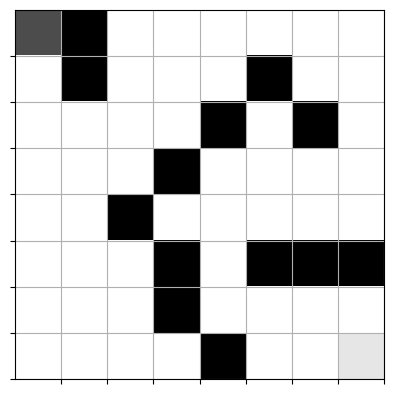

In [12]:
qmaze = TreasureMaze(maze)
show(qmaze)

In the next code block, you will build your model using the <b>build_model</b> function and train it using deep Q-learning. Note: This step takes several minutes to fully run.



In [13]:
model = build_model(maze)
qtrain(model, maze, n_epoch=1000, max_memory=8*maze.size, data_size=32, target_update_freq=50)

D:\JupyterLab\pirate-intelligent-agent\cs370-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch: 000/999 | Loss: 0.0706 | Episodes: 10 | Win count: 1 | Win rate: 0.000 | time: 1.9 seconds
Epoch: 001/999 | Loss: 0.0012 | Episodes: 136 | Win count: 1 | Win rate: 0.000 | time: 5.4 seconds
Epoch: 002/999 | Loss: 0.0017 | Episodes: 7 | Win count: 2 | Win rate: 0.000 | time: 5.6 seconds
Epoch: 003/999 | Loss: 0.0020 | Episodes: 14 | Win count: 3 | Win rate: 0.000 | time: 6.0 seconds
Epoch: 004/999 | Loss: 0.0102 | Episodes: 138 | Win count: 3 | Win rate: 0.000 | time: 9.7 seconds
Epoch: 005/999 | Loss: 0.0105 | Episodes: 1 | Win count: 4 | Win rate: 0.000 | time: 9.7 seconds
Epoch: 006/999 | Loss: 0.0015 | Episodes: 134 | Win count: 4 | Win rate: 0.000 | time: 13.3 seconds
Epoch: 007/999 | Loss: 0.0014 | Episodes: 134 | Win count: 4 | Win rate: 0.000 | time: 17.2 seconds
Epoch: 008/999 | Loss: 0.0010 | Episodes: 141 | Win count: 4 | Win rate: 0.000 | time: 20.8 seconds
Epoch: 009/999 | Loss: 0.0006 | Episodes: 136 | Win count: 4 | Win rate: 0.000 | time: 24.3 seconds
Epoch: 010/9

<div class="alert alert-block alert-warning" style="color:black;">
<b>Note: </b> This cell will check to see if the model passes the completion check.
</div>

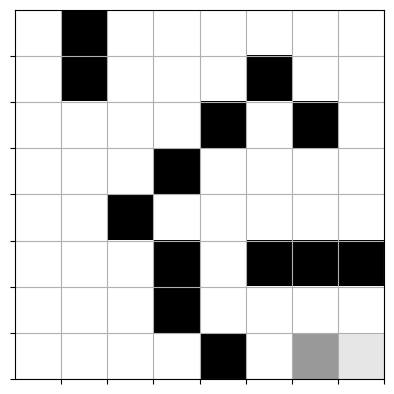

In [14]:
completion_check(model, qmaze)
show(qmaze)

This cell will test your model for one game. It will start the pirate at the top-left corner and run <b>play_game()</b>. The agent should find a path from the starting position to the target (treasure). The treasure is located in the bottom-right corner.

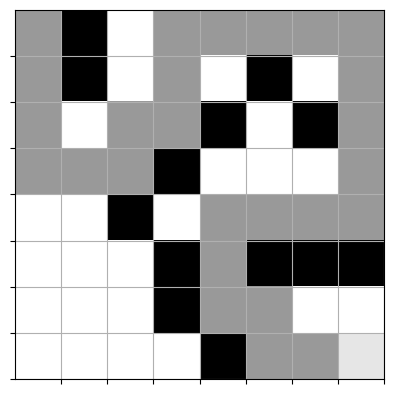

In [15]:
pirate_start = (0, 0)
play_game(model, qmaze, pirate_start)
show(qmaze)

In [16]:
model.save('checkpoint_final_model.keras')
print("Checkpoint saved")

Checkpoint saved
